## K-Nearest Neighbors (K-Vizinhos mais Próximos)

Dado um conjunto de observações

$$
V = \{(\vec{x_{i}}, y_{i})\}_{i=1}^{n}
$$
    
onde

$$
\vec{x_i} =
\begin{bmatrix}
  x_{i1} \\ x_{i2} \\ \vdots \\ x_{id}
  \end{bmatrix} \in \mathbb{R^{d}} \quad
  y_i \in \mathbb{N}
$$

ou seja, $\vec{x_i}$ é um vetor de atributos e $y_i$ é um rótulo sendo, nesse caso, um valor discreto.

Vamos definir o conjunto de rótulos como sendo:

$$
C = \{ y_i \}_{i=1}^{m}, \quad m \leq n
$$

Dado um novo vetor de atributos $\vec{z}$, vamos calcular a distância Euclidiana entre $\vec{z}$ e todos os vetores de treino $\vec{x_i}$:

$$
d(\vec{z}, \vec{x_i}) = \sqrt{\sum_{k=1}^{d}(z_{k} - x_{ik})^{2}}
$$


Conseguimos assim determinar o vetor $\omega$, o vetor de distâncias de $\vec{z}$ a cada um dos $\vec{x_i}$

$$
\vec{\omega} =
\begin{bmatrix}
  d(\vec{z}, \vec{x_1}) \\ d(\vec{z}, \vec{x_2}) \\ \vdots \\ d(\vec{z}, \vec{x_n})
\end{bmatrix} \in \mathbb{R^{n}}
$$

Ordenando $\omega$, encontramos as $k$ menores distâncias e seus respectivos índices:

$$
I_k = \operatorname{arg sort}(\vec{\omega})_{1:k}
$$

Os rótulos correspondentes aos $k$ vizinhos mais próximos são então:

$$
\{y_{(1)}, y_{(2)}, \ldots, y_{(k)}\} \quad \text{onde } y_{(i)} = y_{I_k(i)}
$$


Por fim, dada a função indicadora $\mathbb{I}(\cdot)$:

$$
\mathbb{I}(A) =
\begin{cases}
1, & \text{se a condição } A \text{ é verdadeira} \\
0, & \text{caso contrário}
\end{cases}
$$


determinamos o rótulo predito $\hat{y}$ como sendo aquele que maximiza o número de ocorrências entre os $k$ vizinhos mais próximos:

$$
\hat{y} = \arg\max_{c \in C} \sum_{i=1}^{k} \mathbb{I}(y_{(i)} = c)
$$


## Implementação Básica do KNN

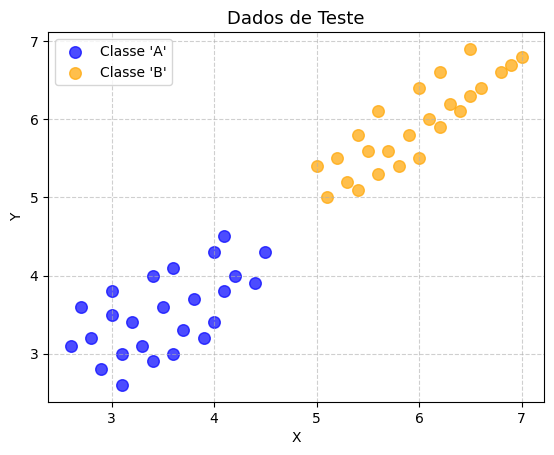

In [44]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt(
    "data.csv",
    delimiter=",",
    dtype=str,
    skiprows=1
)

X = data[:, 0].astype(float)

Y = data[:, 1].astype(float)

C = data[:, 2]

V = np.column_stack((X, Y))

for classe, cor in zip(np.unique(C), ['blue', 'orange']):
    pontos = V[C == classe]
    plt.scatter(pontos[:, 0], pontos[:, 1], label=f'Classe {classe}', color=cor, s=70, alpha=0.7)

plt.title('Dados de Teste', fontsize=13)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Construção do KNN

In [45]:
from collections import Counter
from math import sqrt

def dist(x, z):
    return sqrt(np.sum((np.array(x) - np.array(z))**2))

def knn(V, labels, z, k):
    omega = np.array([dist(x_i, z) for x_i in V])
    Ik = np.argsort(omega)[:k]
    Ck = labels[Ik]
    y = Counter(Ck).most_common(1)[0][0]
    return y, Ik

### Visualização de $\vec{z}$ com os demais dados de teste

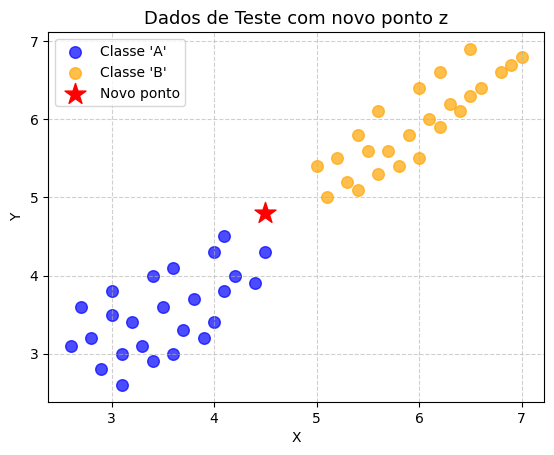

In [46]:
z = np.array([4.5, 4.8])

for classe, cor in zip(np.unique(C), ['blue', 'orange']):
    pontos = V[C == classe]
    plt.scatter(pontos[:, 0], pontos[:, 1], label=f'Classe {classe}', color=cor, s=70, alpha=0.7)
plt.scatter(z[0], z[1], color='red', marker='*', s=250, label=f'Novo ponto')

plt.title('Dados de Teste com novo ponto z', fontsize=13)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Dado um certo $k$, esses são os $k$ vizinhos mais próximos de $\vec{z}$:

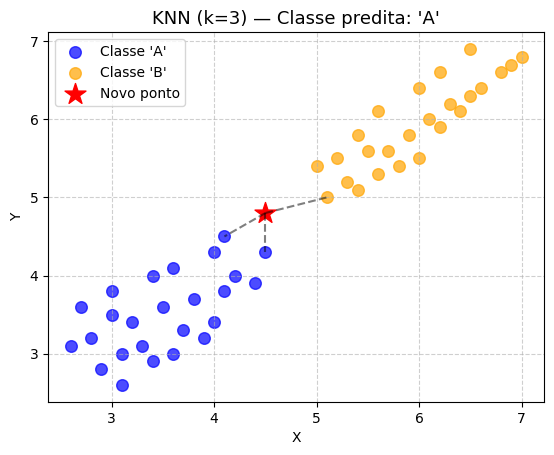

In [47]:
k = 3

label_pred, Ik = knn(V, C, z, k)

for classe, cor in zip(np.unique(C), ['blue', 'orange']):
    pontos = V[C == classe]
    plt.scatter(pontos[:, 0], pontos[:, 1], label=f'Classe {classe}', color=cor, s=70, alpha=0.7)

for i in Ik:
    plt.plot([z[0], V[i, 0]], [z[1], V[i, 1]], 'k--', alpha=0.5)

plt.scatter(z[0], z[1], color='red', marker='*', s=250, label=f'Novo ponto')
plt.title(f'KNN (k={k}) — Classe predita: {label_pred}', fontsize=13)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()